# POWERLIFT PREDICTOR
### Predict the score for any one of the following three lifts, based on the other two:
- Squat
- Bench Press
- Deadlift

This Data Science analysis is performed on a [Powerlifting Dataset](https://www.kaggle.com/datasets/open-powerlifting/powerlifting-database) (pre-filtered for memory usage purposes), to perform Data preprocessing, Data cleaning, Feature Engineering, Exploratory Data Analysis (EDA), Data Visualization, Predictive Modeling, Model Evaluation, and Deployment

In [269]:
# IMPORTING LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [270]:
# LOADING DATASET

FILE_PATH = "./powerlifting-dataset.csv"

pldf_raw = pd.read_csv(FILE_PATH, index_col=0)

print("DATASET LOADED")
pldf_raw.shape

DATASET LOADED


(3043013, 6)

The raw dataset will remain unaltered and simply cloned into a new "working" dataframe 

In [271]:
# COPYING RAW DATASET INTO WORKING DATAFRAME

df = pldf_raw.copy()

df.head()

,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg
0,F,33.0,58.30,80.0,60.0,107.5
1,F,43.0,73.10,105.0,67.5,110.0
2,M,15.5,67.40,100.0,62.5,105.0
3,M,35.0,66.65,137.5,122.5,170.0
4,M,26.5,72.45,90.0,50.0,125.0


Formatting the columns allows for easy reading and handling

In [272]:
# RENAMING AND FORMAT COLUMNS

df.rename(
    columns = {
        "BodyweightKg": "WEIGHT",
        "Best3SquatKg": "SQUAT",
        "Best3BenchKg": "BENCH",
        "Best3DeadliftKg": "DEADLIFT"
    },
    inplace = True
)
df.rename(columns = lambda col: col.upper(), inplace=True)
df.head(5)

,SEX,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT
0,F,33.0,58.30,80.0,60.0,107.5
1,F,43.0,73.10,105.0,67.5,110.0
2,M,15.5,67.40,100.0,62.5,105.0
3,M,35.0,66.65,137.5,122.5,170.0
4,M,26.5,72.45,90.0,50.0,125.0


After formatting the columns, each feature will be examined individually, starting with the descriptions (distrbutions, counts, values, etc)

In [273]:
# CHECKING "SEX" VALUES AND COUNTS

print(df["SEX"].value_counts(dropna=False))

SEX
M     2290122
F      752828
Mx         63
Name: count, dtype: int64


The "SEX" value "Mx" does not correspond to either Male or Female. Its purpose is unclear.
This issue can be approached by:
- Imputing "Mx" values -- using KNN or alternative
- Omitting the rows: losing 63 values (from over 3 million)
- Omitted the SEX column: losing an entire attribute due to a few unusual values

In [274]:
# CHECKING "AGE" VALUES AND COUNTS

n_null_age = df[pd.isna(df["AGE"])].shape[0]
pct_null_age = np.round(n_null_age/df.shape[0]*100, 2)

print("Amount of missing AGE values:")
print(f"{n_null_age} of {df.shape[0]} ({pct_null_age}%)")
print('\n')

age_description = df["AGE"].describe().round().astype(int)
print(age_description)

Amount of missing AGE values:
1070337 of 3043013 (35.17%)


count    1972676
mean          31
std           13
min            0
25%           20
50%           28
75%           38
max           98
Name: AGE, dtype: int64


The AGE column seems to have values of 0. 
Similar to the issue with the SEX column, this issue has a few possible approaches:
- Impute the invalid values
- Omit the rows
- Omit the entire AGE column

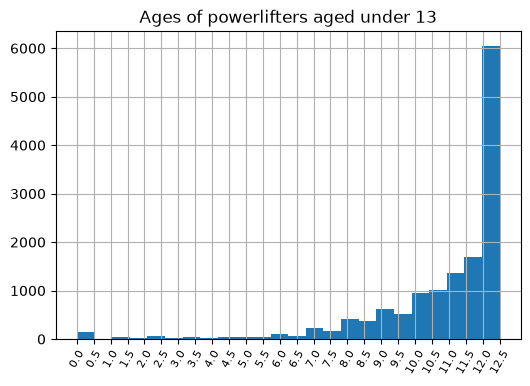

In [275]:
# PLOTTING UNDERAGE POWERLIFTERS' AGES (DISTRIBUTION)

young_kids = df[df["AGE"] < 13]

plt.figure()
plt.xticks([x/2 for x in range(0, 26, 1)])
plt.title("Ages of powerlifters aged under 13")

young_kids["AGE"].hist(
    xlabelsize=8,
    xrot=60,
    figsize=(6, 4),
    bins=24     # bins set to double that of total, to capture half-year increment (ex: 11.5)
)
plt.show()

There are also alarmingly low values in this column, even as low as 0.5!
This has to be a data entry error.
Nearly 14 thousand rows are from children under 13.
For ethical purposes, these may need to be omitted entirely.

Further investigation is due to determine how much of these are errors in data entry.
There is a notable increase in count from x=10 onwards, so ages below that level must be prioritized for data cleaning.

In [276]:
# CHECKING "WEIGHT" VALUES AND 5-NUMBER SUMMARY

df["WEIGHT"].describe().round(2)

count    3004645.00
mean          84.17
std           22.63
min           10.00
25%           67.20
50%           81.95
75%           98.79
max          300.00
Name: WEIGHT, dtype: float64

The WEIGHT column seems to contain some values which are alarmingly low and alarmingly high.
The validity of these values must be confirmed via further analysis.

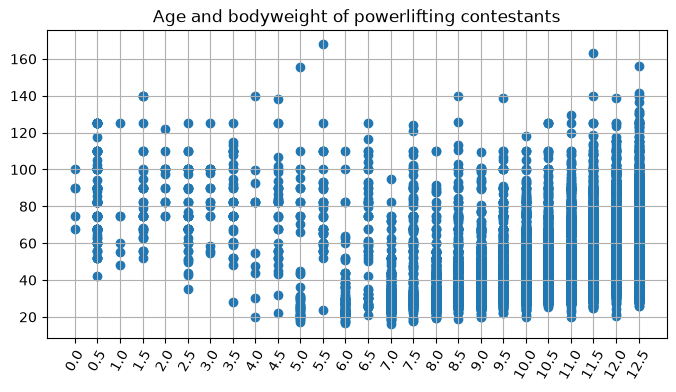

In [277]:
# COMPARING BODYWEIGHTS OF CONTESTANTS OF DIFFERENT AGES

plt.figure(figsize = (8, 4))
plt.xticks(
    ticks = [x/2 for x in range(0, 26, 1)],
    rotation = 60
)
plt.title("Age and bodyweight of powerlifting contestants")
plt.scatter(x=young_kids["AGE"], y=young_kids["WEIGHT"])
plt.grid(True)
plt.show()

Not only are extremely low AGE values guaranteed to be faulty entries, but many individuals have unrealistic WEIGHT values for their age (ex: a 6-year-old weighing 170kg, AKA ~374 lbs).
These values need to be handled by imputation or omission.

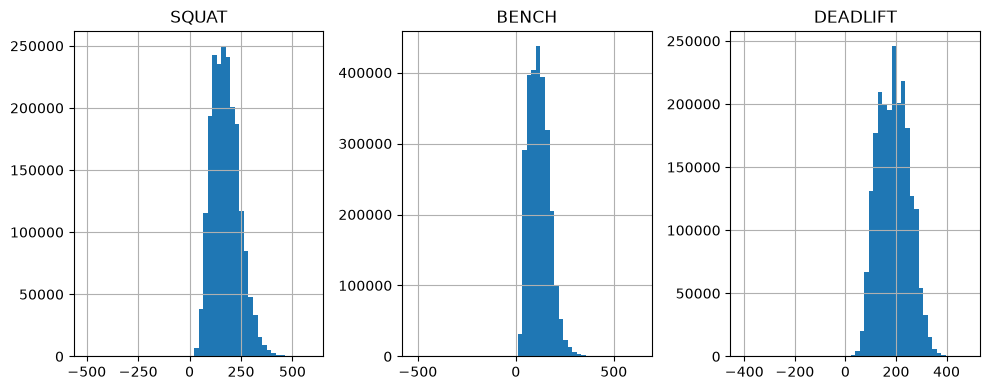

,SQUAT,BENCH,DEADLIFT
count,2033844.00,2684447.00,2206190.00
mean,174.45,118.13,190.11
std,68.37,53.56,62.03
min,-508.02,-522.50,-410.00
25%,122.50,75.00,142.50
50%,170.00,115.00,190.00
75%,217.72,151.95,235.00
max,595.00,635.50,487.50


In [278]:
# ANALYZING AND PLOTTING LIFT SCORES

lifts = ["SQUAT", "BENCH", "DEADLIFT"]

fig, axes = plt.subplots(ncols=len(lifts), figsize=(10, 4))

for lift,ax in zip(lifts, axes):
    ax.hist(df[lift], bins=50)
    ax.set_title(lift)
    ax.grid(True)

plt.tight_layout()
plt.show()

df[lifts].describe().round(2)

The presence of lift scores below zero indicates one or more of the followinga:
- errors in data entry
- scoring convention (failed attempts are recorded as negative)

This formatting system is leading to data science issues which can be fixed with either:
- replacing the invalid scores via imputation
- omitting the rows containing the invalid scores

In [279]:
# EXAMINING NEGATIVE VALUES

def get_invalid_scores(df):
    invalid_lifts = pd.DataFrame()

    for lift in lifts:
        invalid_lifts.loc[lift.capitalize(), "n_negatives"] = df[df[lift] < 0].shape[0]
        invalid_lifts.loc[lift.capitalize(), "n_nulls"] = df[np.isnan(df[lift])].shape[0]
        

    invalid_lifts = invalid_lifts.astype(int)

    invalid_lifts.loc["Total"] = invalid_lifts.sum()
    invalid_lifts["Total"] = invalid_lifts.sum(axis=1)

    print(f"Invalid lift scores: ({(invalid_lifts.loc["Total", "Total"]/df.shape[0] * 100).round(2)}%)")
    return invalid_lifts

get_invalid_scores(df)

Invalid lift scores: (72.69%)


,n_negatives,n_nulls,Total
Squat,3024,1009169,1012193
Bench,3125,358566,361691
Deadlift,1187,836823,838010
Total,7336,2204558,2211894


Over 2.2 million samples contain invalid scores, which is over 72% of the entire dataset. This is a big problem.
Omitting all these values would be losing lots of valuable data, so imputation may be necessary.
Let's start with fixing the negative values. 

Over 7000 samples have at least one negative score. These can be turned into nulls and then imputed.
However, imputation becomes less practical for a given sample if that sample also has multiple invalid scores.
A small amount of samples may even have invalid scores for all three lifts. Those must be removed, without a doubt.

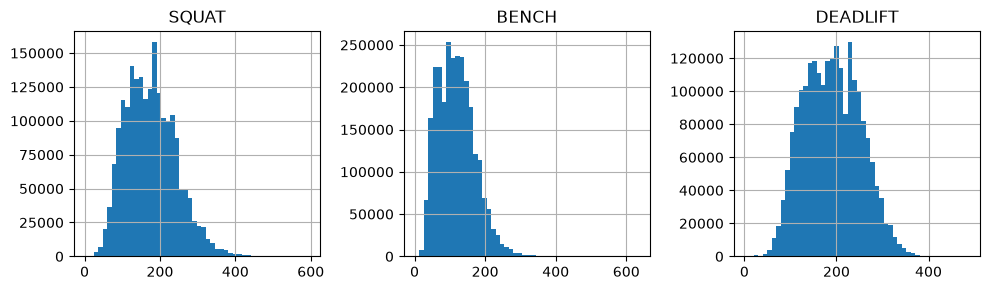

,SQUAT,BENCH,DEADLIFT
count,2030820.00,2681322.00,2205003.00
mean,175.01,118.45,190.33
std,66.82,52.70,61.30
min,1.00,1.00,1.00
25%,124.74,75.00,142.50
50%,170.00,115.00,190.00
75%,217.72,151.95,235.00
max,595.00,635.50,487.50


In [280]:
# TURNING ALL NEGATIVE SCORES INTO NULLS

fig, axes = plt.subplots(ncols = len(lifts), figsize=(10, 3))
for lift, ax in zip(lifts, axes):
    neg_val_idx = df.loc[df[lift] < 0, lift].index
    df.loc[neg_val_idx, lift] = None

    ax.set_title(lift)
    ax.grid(True)
    ax.hist(df[lift], bins=50)

plt.tight_layout()
plt.show()
df[lifts].describe().round(2)

There are no more negative values, as confirmed by the descriptions of the scores, although they have minimums of only 1, which is likely to be from error in data entry. The histogram distributions have a standard unimodal shape, indicating that the data is becoming more properly formatted. However, there are still many NULL values to handle, along with the newly converted ones. That will be the next step.

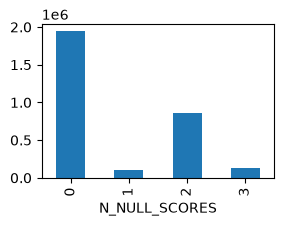

N_NULL_SCORES
0    1945103
2     863920
3     125032
1     108958
Name: count, dtype: int64


Before removing unscored: 3043013 total samples
After removing unscored: 2917981 total samples


In [281]:
# REMOVING ROWS MISSING SCORES FOR ALL THREE LIFTS

df["N_NULL_SCORES"] = np.zeros(df.shape[0]).astype(int)

for lift in lifts:
    df.loc[np.isnan(df[lift]), "N_NULL_SCORES"] += 1

plt.figure()
df["N_NULL_SCORES"].value_counts().sort_index().plot(kind="bar", figsize=(3, 2))
plt.show()
print(df["N_NULL_SCORES"].value_counts())

print('\n')

print(f"Before removing unscored: {df.shape[0]} total samples")
df = df[df["N_NULL_SCORES"] != 3]
print(f"After removing unscored: {df.shape[0]} total samples")

Over 100k samples can be imputed since they are only missing 1 score, but a slightly higher number of other samples MUST be removed since they have no recorded scores at all. 
Even more surprising is that a significantly larger chunk of samples are missing exactly TWO values. Luckily, though, the vast majority of the dataset has score values for all lifts.

In [283]:
# CHECK AMOUNT OF INVALID SCORES AGAIN

get_invalid_scores(df)

Invalid lift scores: (62.95%)


,n_negatives,n_nulls,Total
Squat,0,887161,887161
Bench,0,236659,236659
Deadlift,0,712978,712978
Total,0,1836798,1836798


The amount of invalid scores has reduced from 2.2 million to 1.8 million. That's roughly 400k samples corrected, which is good progress. Total total percentage is also down from 72% to 62%, a difference of 10% so far, despite the fact that the dataset has shrunk in size. Still, a lot of cleaning remains to be done. The next step is to impute the missing scores for samples missing only 1 score.